In [1]:
# ==============================================================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==============================================================================
import pandas as pd # untuk manipulasi data tabel (seperti Excel)
import re # untuk regular expression (pembersihan teks)
import matplotlib.pyplot as plt # untuk visualisasi data (grafik)
import seaborn as sns # untuk visualisasi Confusion Matrix yang lebih cantik
import numpy as np

# LIBRARY NATURAL LANGUAGE PROCESSING (NLTK) untuk Preprocessing
import nltk
from nltk.tokenize import word_tokenize # untuk memecah kalimat menjadi kata
from nltk.corpus import stopwords # Daftar kata umum (stopwords)

# Library Scikit-Learn untuk Machine Learning
from sklearn.model_selection import train_test_split # Untuk split data
from sklearn.feature_extraction.text import TfidfVectorizer # Mengubah teks menjadi bentuk angka (vektor) menggunakan TF-IDF
from sklearn.feature_selection import SelectKBest, chi2 # Seleksi fitur terbaik berdasarkan statistik chi-square
# Model Decision Tree untuk klasifikasi
from sklearn.tree import DecisionTreeClassifier  
# Visualisasi pohon keputusan
from sklearn.tree import plot_tree  
# Menampilkan aturan decision tree dalam bentuk teks
from sklearn.tree import export_text  
# Analisis overfitting
from sklearn.model_selection import cross_validate, learning_curve
# Evaluasi model machine learning
from sklearn.metrics import (
    classification_report,   # precision, recall, f1-score
    accuracy_score,          # akurasi model
    confusion_matrix,        # matriks prediksi vs aktual
    ConfusionMatrixDisplay   # visualisasi confusion matrix
)

# Download resource NLTK yang diperlukan
# 'punkt' dan 'punkt_tab': Untuk Tokenization
# 'stopwords'            : Untuk kamus Stopwords (the, is, a, …)
for resource in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


In [2]:
# ==============================================================================
# TAHAP 1: PERSIAPAN DATA (FILTERING & MAPPING)
# ==============================================================================

print("Membaca dataset dari Kaggle...")

# Input file path data training
training_data_path = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv'
testing_data_path = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv'

df_train_raw = pd.read_csv(training_data_path)
df_test_raw = pd.read_csv(testing_data_path)

Membaca dataset dari Kaggle...


In [3]:
df_train_raw

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [4]:
df_test_raw

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


In [5]:
# Menggabungkan Judul dan Deskripsi Berita
df_train_raw['text'] = df_train_raw['Title'] + " " + df_train_raw['Description']
df_test_raw['text'] = df_test_raw['Title'] + " " + df_test_raw['Description']

In [6]:
df_train_raw

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."
...,...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...,Pakistan's Musharraf Says Won't Quit as Army C...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...,Renteria signing a top-shelf deal Red Sox gene...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...,Saban not going to Dolphins yet The Miami Dolp...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,Today's NFL games PITTSBURGH at NY GIANTS Time...


In [7]:
df_test_raw

,Class Index,Title,Description,text
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,Fears for T N pension after talks Unions repre...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...
...,...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...,Around the world Ukrainian presidential candid...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...,Void is filled with Clement With the supply of...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...,Martinez leaves bitter Like Roger Clemens did ...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...,5 of arthritis patients in Singapore take Bext...


In [8]:
# Membuang Class Index = 3 (Business) agar sesuai requirement 3 kelas saja
# Mapping Kelas ke Bahasa Indonesia (1=World, 2=Sports, 4=Sci/Tech)

TARGET_LABELS = {
    1: "Politik", 
    2: "Olahraga", 
    4: "Teknologi"
}
 
def filter_and_map(df):
    """
    Menyaring baris hanya untuk label 1, 2, 4 lalu
    memetakan angka ke nama kategori yang sesuai.
    """
    df = df[df["Class Index"].isin(TARGET_LABELS.keys())].copy()
    df["label"] = df["Class Index"].map(TARGET_LABELS)
    return df.reset_index(drop=True)
 
df_train_clean = filter_and_map(df_train_raw)
df_test_clean  = filter_and_map(df_test_raw)

In [9]:
# # Menyimpan hasil preprocessing ke file CSV
# df_train_clean.to_csv("train_clean.csv", index=False)
# df_test_clean.to_csv("test_clean.csv", index=False)

# # Menyimpan 10 baris pertama hasil preprocessing ke file CSV
# df_train_clean.head(10).to_csv("train_clean-10.csv", index=False)
# df_test_clean.head(10).to_csv("test_clean-10.csv", index=False)

# print("File train_clean.csv dan test_clean.csv berhasil disimpan (10 baris pertama).")
# print("File train_clean.csv dan test_clean.csv berhasil disimpan.")

In [10]:
df_train_clean

,Class Index,Title,Description,text,label
0,4,"'Madden,' 'ESPN' Football Score in Different W...",Reuters - Was absenteeism a little high\on Tue...,"'Madden,' 'ESPN' Football Score in Different W...",Teknologi
1,4,Group to Propose New High-Speed Wireless Forma...,Reuters - A group of technology companies\incl...,Group to Propose New High-Speed Wireless Forma...,Teknologi
2,4,AOL to Sell Cheap PCs to Minorities and Senior...,Reuters - America Online on Thursday said it\p...,AOL to Sell Cheap PCs to Minorities and Senior...,Teknologi
3,4,Companies Approve New High-Capacity Disc Forma...,Reuters - A group of consumer electronics\make...,Companies Approve New High-Capacity Disc Forma...,Teknologi
4,4,Missing June Deals Slow to Return for Software...,Reuters - The mystery of what went wrong for t...,Missing June Deals Slow to Return for Software...,Teknologi
...,...,...,...,...,...
89995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...,Pakistan's Musharraf Says Won't Quit as Army C...,Politik
89996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...,Renteria signing a top-shelf deal Red Sox gene...,Olahraga
89997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...,Saban not going to Dolphins yet The Miami Dolp...,Olahraga
89998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,Today's NFL games PITTSBURGH at NY GIANTS Time...,Olahraga


In [11]:
df_test_clean

,Class Index,Title,Description,text,label
0,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...,Teknologi
1,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...,Teknologi
2,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...,Teknologi
3,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...,Teknologi
4,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...,Open Letter Against British Copyright Indoctri...,Teknologi
...,...,...,...,...,...
5695,2,Mortaza strikes to lead superb Bangladesh rally,Paceman Mashrafe Mortaza claimed two prize sca...,Mortaza strikes to lead superb Bangladesh rall...,Olahraga
5696,1,Powell pushes diplomacy for N. Korea,WASHINGTON -- Outgoing Secretary of State Coli...,Powell pushes diplomacy for N. Korea WASHINGTO...,Politik
5697,1,Around the world,Ukrainian presidential candidate Viktor Yushch...,Around the world Ukrainian presidential candid...,Politik
5698,2,Void is filled with Clement,With the supply of attractive pitching options...,Void is filled with Clement With the supply of...,Olahraga


In [12]:
# ==========================================
# TAHAP 2: PREPROCESSING
# ==========================================
print("2. Memulai proses Preprocessing...")

# Ambil daftar stopword bahasa Inggris dari NLTK
stop_words_english = set(stopwords.words('english'))

2. Memulai proses Preprocessing...


In [13]:
print(stop_words_english)
print("Jumlah stopword:", len(stop_words_english))

{'so', 'ain', "doesn't", 'what', 'needn', 'into', 'by', 'her', "hadn't", 'very', 'can', 'shan', "won't", 'where', 'your', 'over', 'too', 'me', "wasn't", 'myself', 'yours', 'have', 'him', 'other', 'our', 'this', "it's", 'no', "didn't", "they'd", 'his', 'down', 'a', 'once', "don't", "mightn't", 'before', 'do', "i'm", 'whom', 'same', 'ma', "hasn't", 'd', "he'll", 'theirs', "they'll", 'wouldn', 'or', 'those', "i'll", "it'd", 'shouldn', 'such', "it'll", 'most', "couldn't", 'ours', 'until', 's', 'll', "they've", "we've", 'there', 'in', 'i', 'because', 'won', "they're", 'than', 'did', "wouldn't", 'm', 'been', 'mustn', 'not', 'with', "we're", "you'll", 'be', "shouldn't", "haven't", 'that', 'only', 'yourself', 'doesn', 'o', 'should', "you'd", "you're", "that'll", 'for', "she'd", "he's", 'on', 'don', 'wasn', 'was', 'yourselves', 'here', 'itself', "i've", 'from', 'some', 'these', 'against', "weren't", 'himself', 'are', 'themselves', 'through', 'weren', 'haven', 'own', 'again', 'he', 'ourselves', 

In [14]:
def preprocess(text):
    # Case Folding: Mengubah seluruh huruf menjadi huruf kecil
    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', ' ', text)     # Hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()  # Rapikan spasi berlebih
    
    # Tokenization: Memecah kalimat utuh menjadi potongan kata (list)
    tokens = word_tokenize(text)
    
    # Stopword Removal: Membuang kata-kata sambung/umum yang tidak penting
    clean_tokens = [
        token for token in tokens
        if token not in stop_words_english and len(token) > 1
    ]
    
    # Gabungkan kembali list kata menjadi string (karena TF-IDF butuh input string)
    preprocessed_text = " ".join(clean_tokens)
    return preprocessed_text

# Terapkan preprocessing ke data latih dan data uji
print("   -> Memproses Data Training...")
df_train_clean['clean_text'] = df_train_clean['text'].apply(preprocess)

print("   -> Memproses Data Testing...")
df_test_clean['clean_text'] = df_test_clean['text'].apply(preprocess)

   -> Memproses Data Training...
   -> Memproses Data Testing...


In [15]:
df_train_clean

,Class Index,Title,Description,text,label,clean_text
0,4,"'Madden,' 'ESPN' Football Score in Different W...",Reuters - Was absenteeism a little high\on Tue...,"'Madden,' 'ESPN' Football Score in Different W...",Teknologi,madden espn football score different ways reut...
1,4,Group to Propose New High-Speed Wireless Forma...,Reuters - A group of technology companies\incl...,Group to Propose New High-Speed Wireless Forma...,Teknologi,group propose new high speed wireless format r...
2,4,AOL to Sell Cheap PCs to Minorities and Senior...,Reuters - America Online on Thursday said it\p...,AOL to Sell Cheap PCs to Minorities and Senior...,Teknologi,aol sell cheap pcs minorities seniors reuters ...
3,4,Companies Approve New High-Capacity Disc Forma...,Reuters - A group of consumer electronics\make...,Companies Approve New High-Capacity Disc Forma...,Teknologi,companies approve new high capacity disc forma...
4,4,Missing June Deals Slow to Return for Software...,Reuters - The mystery of what went wrong for t...,Missing June Deals Slow to Return for Software...,Teknologi,missing june deals slow return software cos re...
...,...,...,...,...,...,...
89995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...,Pakistan's Musharraf Says Won't Quit as Army C...,Politik,pakistan musharraf says quit army chief karach...
89996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...,Renteria signing a top-shelf deal Red Sox gene...,Olahraga,renteria signing top shelf deal red sox genera...
89997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...,Saban not going to Dolphins yet The Miami Dolp...,Olahraga,saban going dolphins yet miami dolphins put co...
89998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,Today's NFL games PITTSBURGH at NY GIANTS Time...,Olahraga,today nfl games pittsburgh ny giants time line...


In [16]:
df_test_clean

,Class Index,Title,Description,text,label,clean_text
0,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...,Teknologi,race second private team sets launch date huma...
1,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...,Teknologi,ky company wins grant study peptides ap ap com...
2,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...,Teknologi,prediction unit helps forecast wildfires ap ap...
3,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...,Teknologi,calif aims limit farm related smog ap ap south...
4,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...,Open Letter Against British Copyright Indoctri...,Teknologi,open letter british copyright indoctrination s...
...,...,...,...,...,...,...
5695,2,Mortaza strikes to lead superb Bangladesh rally,Paceman Mashrafe Mortaza claimed two prize sca...,Mortaza strikes to lead superb Bangladesh rall...,Olahraga,mortaza strikes lead superb bangladesh rally p...
5696,1,Powell pushes diplomacy for N. Korea,WASHINGTON -- Outgoing Secretary of State Coli...,Powell pushes diplomacy for N. Korea WASHINGTO...,Politik,powell pushes diplomacy korea washington outgo...
5697,1,Around the world,Ukrainian presidential candidate Viktor Yushch...,Around the world Ukrainian presidential candid...,Politik,around world ukrainian presidential candidate ...
5698,2,Void is filled with Clement,With the supply of attractive pitching options...,Void is filled with Clement With the supply of...,Olahraga,void filled clement supply attractive pitching...


In [17]:
# Tampilkan perbandingan sebelum dan sesudah Preprocessing
print("\n--- Contoh Hasil Preprocessing ---")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL  : {df_train_clean['text'].iloc[i]}")
    print(f"    CLEAN     : {df_train_clean['clean_text'].iloc[i]}")
    print(f"    LABEL     : {df_train_clean['label'].iloc[i]}")


--- Contoh Hasil Preprocessing ---

[1] ORIGINAL  : 'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 2005" came out that day,\and some fans of the football simulation are rabid enough to\take a sick day to play it.
    CLEAN     : madden espn football score different ways reuters reuters absenteeism little high tuesday among guys office ea sports would like think madden nfl came day fans football simulation rabid enough take sick day play
    LABEL     : Teknologi

[2] ORIGINAL  : Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said they\will propose a new wireless networking standard up to 10 times\the speed of the current generation.
    CLEAN     : group propose new high spee

In [18]:
# Pisahkan Fitur (X) dan Target (y)
# Pemisahan Data Split 80/20

# 1. Ambil data dari train.csv
X_train_full = df_train_clean['clean_text']
y_train_full = df_train_clean['label']

# 2. SPLIT 80% TRAINING dan 20% VALIDATION dari test.csv (Testing Internal)
X_train_80, X_val_20, y_train_80, y_val_20 = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"Jumlah Data Latih (80%): {len(X_train_80)}")
print(f"Jumlah Data Validasi (20%): {len(X_val_20)}")

# 3. Ambil data dari test.csv untuk Pengujian Akhir
X_test = df_test_clean['clean_text']
y_test = df_test_clean['label']
print(f"Jumlah Data Test Final: {len(X_test)}")

Jumlah Data Latih (80%): 72000
Jumlah Data Validasi (20%): 18000
Jumlah Data Test Final: 5700


In [19]:
# ==========================================
# TAHAP 3: REPRESENTASI
# ==========================================
print("\n3. Melakukan Representasi Teks (TF-IDF & Feature Selection)...")

# a. TF-IDF
# MAX_FEATURES = 20000   # Ambil 20.000 kata/frasa paling informatif
vectorizer = TfidfVectorizer(
    # max_features=MAX_FEATURES, 
    # ngram_range=(1, 2), # unigram & bigram
)

# FIT hanya pada 80% data latih!
X_train_80_tfidf = vectorizer.fit_transform(X_train_80)
vocab_size = len(vectorizer.vocabulary_)
print(f"Jumlah kosakata/vocabulary: {vocab_size}")

# Transform untuk Validasi dan Test
X_val_20_tfidf = vectorizer.transform(X_val_20)
X_test_tfidf = vectorizer.transform(X_test)

# b. Feature Selection (Chi-square)
# Memilih 2000 fitur/kata yang memiliki korelasi terkuat dengan label kelas
K_BEST = 2000   # Pilih 2.000 fitur terbaik dari 55.000
chi2_selector = SelectKBest(chi2, k=K_BEST)

# FIT hanya pada 80% data latih!
X_train_final = chi2_selector.fit_transform(X_train_80_tfidf, y_train_80)

# Transform untuk Validasi dan Test
X_val_final = chi2_selector.transform(X_val_20_tfidf)
X_test_final = chi2_selector.transform(X_test_tfidf)

# Mengambil nama-nama kata yang lolos seleksi untuk keperluan visualisasi
selected_feature_indexes = chi2_selector.get_support(indices=True)
all_words = vectorizer.get_feature_names_out()
selected_feature_words = [all_words[i] for i in selected_feature_indexes]



3. Melakukan Representasi Teks (TF-IDF & Feature Selection)...
Jumlah kosakata/vocabulary: 51431


In [20]:
# # Eksperimen mencari Hyperparameter terbaik dengan GridSearchCV (hapus comment kalau mau coba :v)
# from sklearn.model_selection import GridSearchCV

# print("Mencari parameter Decision Tree terbaik otomatis (Grid Search)...")

# # 1. Tentukan rentang parameter yang mau diuji
# param_grid = {
#     # kontrol kompleksitas pohon
#     # "max_depth": [3, 5, 8, 12, None],
#     # "min_samples_split": [2, 5, 10, 20],
#     # "min_samples_leaf": [1, 2, 5, 10],
    
#     # fungsi split
#     "criterion": ["gini", "entropy", "log_loss"],
    
#     # fitur yang dipakai saat split
#     "max_features": [None, "sqrt", "log2"],
    
#     # pruning (sangat penting untuk kurangi overfitting)
#     "ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01],
    
#     # handling imbalance data (opsional tapi sering membantu)
#     # "class_weight": [None, "balanced"]
# }

# # 2. Siapkan model dasar
# dt_dasar = DecisionTreeClassifier(
#     min_samples_split=20,
#     max_depth=50,
#     random_state=42
# )

# # 3. Masukkan ke GridSearchCV (cv=5 berarti melakukan Cross-Validation 5x untuk tiap kombinasi)
# grid_search = GridSearchCV(
#     estimator=dt_dasar, 
#     param_grid=param_grid, 
#     cv=5, 
#     n_jobs=-1, # Gunakan seluruh core prosesor agar cepat
#     scoring='accuracy',
#     verbose=2,
#     return_train_score=True
# )

# # 4. Latih untuk mencari yang terbaik
# grid_search.fit(X_train_final, y_train_80)

# # # hasil terbaik
# # print("Best Parameters:", grid_search.best_params_)
# # print("Best CV Score:", grid_search.best_score_)

# # # 5. Gunakan model terbaik tersebut untuk memprediksi
# # best_dt_model = grid_search.best_estimator_
# # y_pred = best_dt_model.predict(X_val_final)

# # print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
# # print("\nClassification Report:\n", classification_report(y_test, y_pred))

# # =========================================================
# # ANALISIS HASIL GRID SEARCH
# # =========================================================

# # ubah hasil jadi dataframe
# results = pd.DataFrame(grid_search.cv_results_)

# # hitung gap overfitting
# results['overfit_gap'] = (
#     results['mean_train_score']
#     - results['mean_test_score']
# )

# # skor gabungan:
# # validation tinggi + overfit rendah
# results['balanced_score'] = (
#     results['mean_test_score']
#     - results['overfit_gap']
# )

# # urutkan model terbaik
# results_sorted = results.sort_values(
#     by='balanced_score',
#     ascending=False
# )
# # tampilkan 10 model terbaik
# print("\n===== TOP 10 MODEL TERBAIK =====")

# cols_show = [
#     'mean_train_score',
#     'mean_test_score',
#     'overfit_gap',
#     'balanced_score',
#     'param_criterion',
#     'param_max_features',
#     'param_ccp_alpha'
# ]

# print(results_sorted[cols_show].head(10))

# # =========================================================
# # PILIH MODEL TERBAIK BERDASARKAN BALANCED SCORE
# # =========================================================

# best_index = results_sorted.index[0]

# best_params = results.loc[best_index, 'params']

# print("\n===== PARAMETER TERBAIK (Overfitting Rendah) =====")
# print(best_params)

# print("\nTrain Accuracy :",
#       results.loc[best_index, 'mean_train_score'])

# print("Validation Accuracy :",
#       results.loc[best_index, 'mean_test_score'])

# print("Overfitting Gap :",
#       results.loc[best_index, 'overfit_gap'])

# # =========================================================
# # LATIH ULANG MODEL TERBAIK
# # =========================================================

# best_dt_model = DecisionTreeClassifier(
#     **best_params,
#     min_samples_split=20,
#     max_depth=50,
#     random_state=42
# )

# best_dt_model.fit(X_train_final, y_train_80)

# # prediksi test set
# y_pred = best_dt_model.predict(X_val_final)

# print("\n===== HASIL TEST SET =====")
# print("Test Accuracy:", accuracy_score(y_test, y_pred))

# print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred))

In [21]:
# # ==========================================
# # EKSPERIMEN berbagai depth (hapus comment kalau mau coba :v)
# # ==========================================
# print("=== EKSPERIMEN BERBAGAI DEPTH ===")

# # Tentukan daftar kedalaman (depth) yang ingin dicoba
# # None berarti pohon dibiarkan tumbuh tanpa batas
# # depths = [1, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, None]
# depths = [1, None]

# # Tempat untuk menyimpan hasil akurasi
# train_scores = []
# test_scores = []
# actual_depths = []
# max_depth_unlimited = 0

# # Melakukan perulangan (looping) untuk setiap kedalaman
# for depth in depths:
#     # Jika depth adalah None, ubah label print agar rapi
#     label_depth = "Tanpa Batas" if depth is None else str(depth)
#     print(f"Melatih model dengan max_depth = {label_depth}...")
    
#     # Inisialisasi dan latih model
#     experiment_model = DecisionTreeClassifier(
#         max_depth=depth,
#         random_state=42,
#         ccp_alpha=0.0001,
#         criterion='entropy',
#     )
#     experiment_model.fit(X_train_final, y_train_80)
    
#     # Prediksi data latih dan hitung akurasi
#     y_pred_train = experiment_model.predict(X_train_final)
#     train_accuracy  = accuracy_score(y_train_80, y_pred_train)
#     train_scores.append(train_accuracy )
    
#     # Prediksi data uji (test) dan hitung akurasi
#     y_pred_test = experiment_model.predict(X_val_final)
#     test_accuracy = accuracy_score(y_test, y_pred_test)
#     test_scores.append(test_accuracy)

#     # ambil depth aktual dari tree yang terbentuk
#     actual_depth = experiment_model.tree_.max_depth
#     actual_depths.append(actual_depth)

#     # Set depth None untuk visualisasi grafik
#     if (max_depth_unlimited < actual_depth):
#         max_depth_unlimited = actual_depth

# # Membuat Tabel Laporan Sederhana
# print("\n=== HASIL EKSPERIMEN ===")
# print(f"{'Max Depth':<15} | {'Depth Aktual':<15} | {'Train Acc':<15} | {'Test Acc':<15} | {'Gap':<10}")
# print("-" * 80)

# for i, depth in enumerate(depths):
#     label = "Tanpa Batas" if depth is None else str(depth)
#     gap = train_scores[i] - test_scores[i]

#     print(f"{label:<15} | {actual_depths[i]:<15} | {train_scores[i]*100:>14.2f}% | {test_scores[i]*100:>14.2f}% | {gap*100:>8.2f}%")

# # Membuat Visualisasi Grafik (Learning Curve)
# # Karena 'None' tidak bisa diplot di grafik dengan garis angka, 
# # kita ganti 'None' menjadi angka yang lebih besar dari daftar sebelumnya (misal 60) untuk visualisasi
# depth_for_plot = [
#     d if d is not None else max([x for x in depths if x is not None]) + 20 
#     for d in depths
# ]

# plt.figure(figsize=(10, 6))
# plt.plot(depth_for_plot, train_scores, label='Akurasi Training', marker='o', color='blue', linewidth=2)
# plt.plot(depth_for_plot, test_scores, label='Akurasi Testing', marker='o', color='red', linewidth=2)

# plt.title('Analisis Overfitting: Kedalaman Pohon vs Akurasi', fontsize=14)
# plt.xlabel('Kedalaman Pohon (max_depth)', fontsize=12)
# plt.ylabel('Akurasi', fontsize=12)
# plt.xticks(depth_for_plot, labels=[str(d) if d is not None else 'Tak Terbatas' for d in depths])
# plt.legend(fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.7)

# # Highlight area Overfitting
# plt.fill_between(depth_for_plot, train_scores, test_scores, color='gray', alpha=0.1, label='Overfitting Gap')

# plt.tight_layout()
# plt.show()

In [22]:
# ==========================================
# TAHAP 4: IMPLEMENTASI DECISION TREE
# ==========================================
print("\n4. Melatih model final Decision Tree...")

# Tentukan Depth terbaik
# BEST_DEPTH = 100

# Inisialisasi model dengan BEST_DEPTH
dt_model = DecisionTreeClassifier(
    # min_samples_split=20,
    # max_depth=BEST_DEPTH, 
    random_state=42,
    # ccp_alpha=0.0005,
    ccp_alpha=0.0001,
    criterion='entropy',
)

# Model HANYA BELAJAR dari data 80%
dt_model.fit(X_train_final, y_train_80)

print(f"Kedalaman Tree Terbentuk: {dt_model.get_depth()}")



4. Melatih model final Decision Tree...
Kedalaman Tree Terbentuk: 343


In [23]:
# Menyimpan model yang sudah ditraining (hapus comment kalau mau nyimpan beneran :v)
import joblib

# Menyimpan 3 komponen penting ke dalam file .pkl (pickle/joblib)
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(chi2_selector, 'chi2_selector.pkl')
joblib.dump(dt_model, 'decision_tree_model.pkl')

print("Model dan pemroses teks berhasil disimpan!")

Model dan pemroses teks berhasil disimpan!



HASIL ANALISIS DAN EVALUASI MODEL

[A] VISUALISASI DECISION TREE GRAFIS
------------------------------


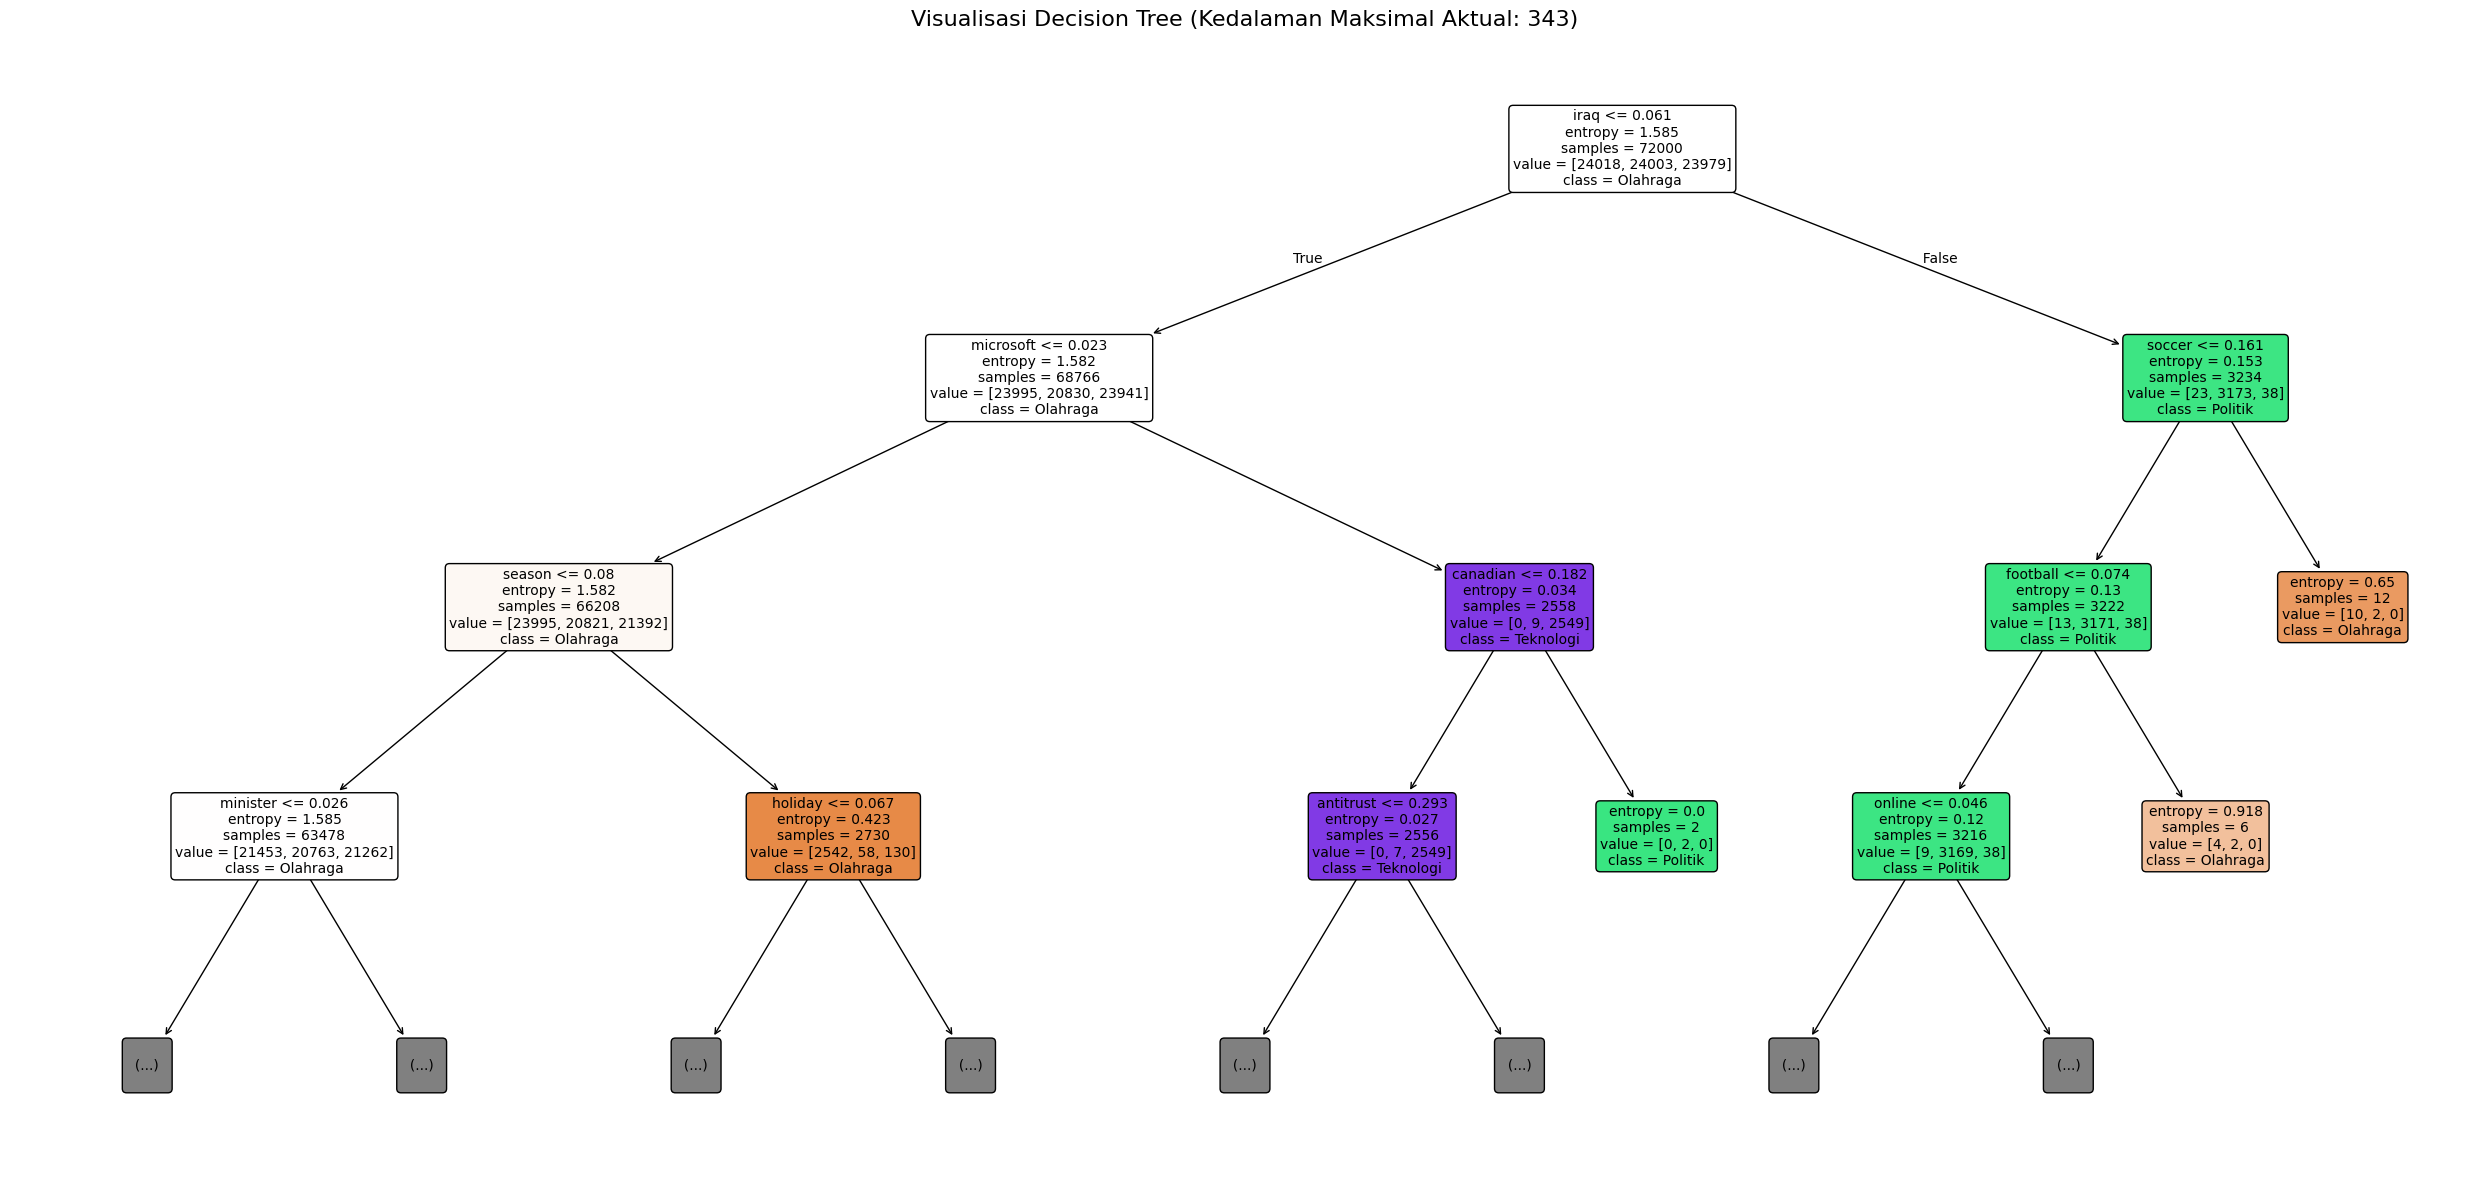

In [24]:
# ==========================================
# TAHAP 5: ANALISIS & EVALUASI
# ==========================================
print("\n" + "="*50)
print("HASIL ANALISIS DAN EVALUASI MODEL")
print("="*50)

# ---------------------------------------------------------
# VISUALISASI DECISION TREE
# ---------------------------------------------------------
print("\n[A] VISUALISASI DECISION TREE GRAFIS")
print("-" * 30)
plt.figure(figsize=(25, 12))
plot_tree(
    dt_model, 
    feature_names=selected_feature_words, 
    class_names=dt_model.classes_, 
    filled=True, 
    rounded=True, 
    max_depth=3, # Dibatasi 3 level agar tidak terlalu bertumpuk di layar
    fontsize=10
)
plt.title(f"Visualisasi Decision Tree (Kedalaman Maksimal Aktual: {dt_model.tree_.max_depth})", fontsize=16)
plt.tight_layout()
plt.savefig("visualisasi-DT.png");
plt.show()

In [25]:
# ---------------------------------------------------------
# INTERPRETASI RULE BERBASIS TEKS
# ---------------------------------------------------------
print("\n[B] INTERPRETASI RULE (ATURAN IF-THEN)")
print("-" * 30)
print("Menampilkan 5 level pertama dari cabang Decision Tree:\n")
rule_text = export_text(dt_model, feature_names=selected_feature_words, max_depth=3)
print(rule_text)


[B] INTERPRETASI RULE (ATURAN IF-THEN)
------------------------------
Menampilkan 5 level pertama dari cabang Decision Tree:

|--- iraq <= 0.06
|   |--- microsoft <= 0.02
|   |   |--- season <= 0.08
|   |   |   |--- minister <= 0.03
|   |   |   |   |--- truncated branch of depth 340
|   |   |   |--- minister >  0.03
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- season >  0.08
|   |   |   |--- holiday <= 0.07
|   |   |   |   |--- truncated branch of depth 43
|   |   |   |--- holiday >  0.07
|   |   |   |   |--- truncated branch of depth 2
|   |--- microsoft >  0.02
|   |   |--- canadian <= 0.18
|   |   |   |--- antitrust <= 0.29
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- antitrust >  0.29
|   |   |   |   |--- class: Teknologi
|   |   |--- canadian >  0.18
|   |   |   |--- class: Politik
|--- iraq >  0.06
|   |--- soccer <= 0.16
|   |   |--- football <= 0.07
|   |   |   |--- online <= 0.05
|   |   |   |   |--- truncated branch of depth 24
|   |   

In [26]:
# from sklearn.tree import _tree

# # ---------------------------------------------------------
# # FUNGSI UNTUK MENGUBAH DECISION TREE MENJADI IF-THEN RULE
# # ---------------------------------------------------------
# def tree_to_rules(tree, feature_names):

#     tree_ = tree.tree_
#     feature_name = [
#         feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
#         for i in tree_.feature
#     ]

#     rules = []

#     def recurse(node, depth, conditions):

#         # Jika bukan leaf node
#         if tree_.feature[node] != _tree.TREE_UNDEFINED:

#             name = feature_name[node]
#             threshold = tree_.threshold[node]

#             # Cabang kiri
#             left_conditions = conditions + [f"IF ({name} <= {threshold:.2f})"]
#             recurse(tree_.children_left[node], depth + 1, left_conditions)

#             # Cabang kanan
#             right_conditions = conditions + [f"IF ({name} > {threshold:.2f})"]
#             recurse(tree_.children_right[node], depth + 1, right_conditions)

#         # Jika leaf node
#         else:
#             value = tree_.value[node]
#             predicted_class = value.argmax()

#             rule = " AND ".join(conditions)
#             rule += f" THEN class = {predicted_class}"

#             rules.append(rule)

#     recurse(0, 1, [])

#     return rules


# # ---------------------------------------------------------
# # MENAMPILKAN RULE IF-THEN
# # ---------------------------------------------------------
# print("\n[D] INTERPRETASI RULE (IF-THEN)")
# print("-" * 40)

# rules = tree_to_rules(dt_model, selected_feature_words)

# for i, rule in enumerate(rules[:10], 1):  # tampilkan 10 rule pertama
#     print(f"Rule {i}:")
#     print(rule)
#     print()


[C] ANALISIS OVERFITTING DENGAN 3 TEKNIK

[1] HOLDOUT VALIDATION (Evaluasi pada 20% Data Split)
--------------------------------------------------
Akurasi Data Latih (80%)    : 93.47%
Akurasi Data Validasi (20%) : 88.50%
Gap Overfitting (Holdout)   : 4.97%

[2] CROSS-VALIDATION (5-Fold pada Data Latih)
--------------------------------------------------
Rata-rata Akurasi Latih CV   : 94.94%
Rata-rata Akurasi Validasi CV: 88.03%
Gap Overfitting (CV)         : 6.91%

[3] LEARNING CURVES (Menghitung performa berdasarkan jumlah data)
--------------------------------------------------
Memproses grafik Learning Curve (Mohon tunggu beberapa detik)...


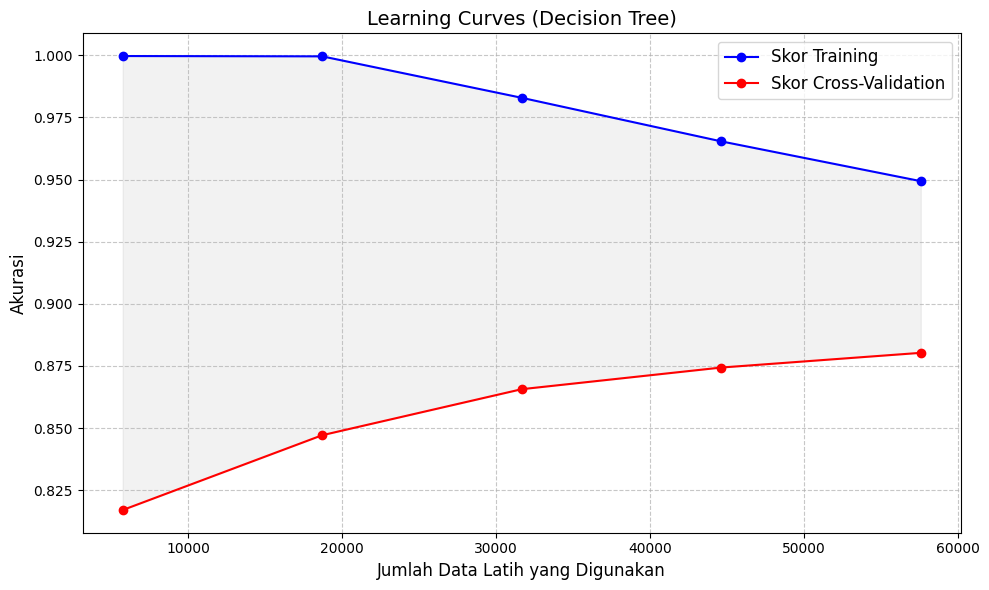

In [27]:
print("\n" + "="*60)
print("[C] ANALISIS OVERFITTING DENGAN 3 TEKNIK")
print("="*60)

# ---------------------------------------------------------
# TEKNIK 1: HOLDOUT VALIDATION (Mengecek dengan data 20%)
# ---------------------------------------------------------
print("\n[1] HOLDOUT VALIDATION (Evaluasi pada 20% Data Split)")
print("-" * 50)

# Prediksi untuk membandingkan Latih (80%) dan Validasi (20%)
y_pred_train = dt_model.predict(X_train_final)
y_pred_val = dt_model.predict(X_val_final)

acc_train_holdout = accuracy_score(y_train_80, y_pred_train)
acc_val_holdout = accuracy_score(y_val_20, y_pred_val)
gap_holdout = acc_train_holdout - acc_val_holdout

print(f"Akurasi Data Latih (80%)    : {acc_train_holdout * 100:.2f}%")
print(f"Akurasi Data Validasi (20%) : {acc_val_holdout * 100:.2f}%")
print(f"Gap Overfitting (Holdout)   : {gap_holdout * 100:.2f}%")

# ---------------------------------------------------------
# TEKNIK 2: CROSS-VALIDATION (5-Fold pada data 80%)
# ---------------------------------------------------------
print("\n[2] CROSS-VALIDATION (5-Fold pada Data Latih)")
print("-" * 50)

cv_results = cross_validate(
    dt_model, 
    X_train_final, 
    y_train_80, 
    cv=5, 
    return_train_score=True,
    scoring='accuracy',
    n_jobs=-1
)

mean_train_cv = np.mean(cv_results['train_score'])
mean_val_cv = np.mean(cv_results['test_score'])
gap_cv = mean_train_cv - mean_val_cv

print(f"Rata-rata Akurasi Latih CV   : {mean_train_cv * 100:.2f}%")
print(f"Rata-rata Akurasi Validasi CV: {mean_val_cv * 100:.2f}%")
print(f"Gap Overfitting (CV)         : {gap_cv * 100:.2f}%")


# ---------------------------------------------------------
# TEKNIK 3: LEARNING CURVES (Visualisasi Pergerakan Belajar)
# ---------------------------------------------------------
print("\n[3] LEARNING CURVES (Menghitung performa berdasarkan jumlah data)")
print("-" * 50)
print("Memproses grafik Learning Curve (Mohon tunggu beberapa detik)...")

train_sizes, train_scores, val_scores = learning_curve(
    dt_model, 
    X_train_final, 
    y_train_80, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5) # Menguji dari 10% data hingga 100% data
)

# Menghitung rata-rata skor per ukuran data
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Visualisasi Grafik
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Skor Training")
plt.plot(train_sizes, val_scores_mean, 'o-', color="red", label="Skor Cross-Validation")

plt.title("Learning Curves (Decision Tree)", fontsize=14)
plt.xlabel("Jumlah Data Latih yang Digunakan", fontsize=12)
plt.ylabel("Akurasi", fontsize=12)
plt.legend(loc="best", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.fill_between(train_sizes, train_scores_mean, val_scores_mean, color='gray', alpha=0.1)
plt.tight_layout()
plt.show()

In [28]:
# =========================================================
# 4. KESIMPULAN AKHIR STATUS MODEL
# =========================================================
print("\n" + "="*60)
print("KESIMPULAN AKHIR STATUS MODEL (DIAGNOSA OTOMATIS)")
print("="*60)

# Mengambil rata-rata dari teknik Holdout dan CV agar evaluasi lebih adil dan stabil
gap_rata_rata = (gap_holdout + gap_cv) / 2
akurasi_latih_rata_rata = (acc_train_holdout + mean_train_cv) / 2

print(f"Indikator Rata-rata Gap (Holdout + CV) : {gap_rata_rata * 100:.2f}%")
print(f"Indikator Rata-rata Akurasi Latih      : {akurasi_latih_rata_rata * 100:.2f}%\n")

# Logika Pengambilan Keputusan
if gap_rata_rata > 0.10:
    print("💡 DIAGNOSA: Model terindikasi mengalami OVERFITTING.")
    print("- Analisis  : Model sangat pintar menghafal data latih (akurasi tinggi), tetapi akurasinya anjlok secara konsisten saat diuji dengan data validasi/CV.")
    print("- Visual    : Pada grafik Learning Curve, garis biru (Latih) dan merah (Validasi) memiliki jarak (gap) abu-abu yang sangat lebar dan tidak menyempit di akhir.")
    print("- Solusi    : 'Pangkas' kerumitan pohon. Coba turunkan 'max_depth', naikkan 'min_samples_split', atau perbesar nilai 'ccp_alpha' (Pruning).")

elif gap_rata_rata <= 0.05 and akurasi_latih_rata_rata < 0.65:
    print("💡 DIAGNOSA: Model terindikasi mengalami UNDERFITTING.")
    print("- Analisis  : Model terlalu sederhana. Ia bahkan kesulitan memahami pola dasar dari data latih (akurasi latih di bawah 65%), sehingga akurasi validasinya pun ikut rendah.")
    print("- Visual    : Pada grafik Learning Curve, garis biru dan merah menempel erat, tetapi keduanya mendatar di titik akurasi yang rendah (misal di kisaran 50%).")
    print("- Solusi    : Berikan model kebebasan untuk belajar lebih detail. Naikkan 'max_depth', atau perbesar jumlah 'K_BEST' pada seleksi fitur Chi-Square.")

else:
    print("💡 DIAGNOSA: Model berada dalam kondisi GOOD FIT (Optimal / Robust).")
    print("- Analisis  : Akurasi latih cukup memuaskan dan jarak (gap) penurunan akurasinya pada data validasi masih dalam batas wajar.")
    print("- Visual    : Pada grafik Learning Curve, garis biru dan merah bergerak mendekat seiring bertambahnya data, menunjukkan kemampuan generalisasi yang baik.")
    print("- Keputusan : Model sudah siap digunakan! Silakan lanjutkan ke Tahap Pengujian Final menggunakan test.csv.")


KESIMPULAN AKHIR STATUS MODEL (DIAGNOSA OTOMATIS)
Indikator Rata-rata Gap (Holdout + CV) : 5.94%
Indikator Rata-rata Akurasi Latih      : 94.20%

💡 DIAGNOSA: Model berada dalam kondisi GOOD FIT (Optimal / Robust).
- Analisis  : Akurasi latih cukup memuaskan dan jarak (gap) penurunan akurasinya pada data validasi masih dalam batas wajar.
- Visual    : Pada grafik Learning Curve, garis biru dan merah bergerak mendekat seiring bertambahnya data, menunjukkan kemampuan generalisasi yang baik.
- Keputusan : Model sudah siap digunakan! Silakan lanjutkan ke Tahap Pengujian Final menggunakan test.csv.



PENGUJIAN FINAL MENGGUNAKAN TEST.CSV

AKURASI FINAL (Real-World Data): 88.68%

              precision    recall  f1-score   support

    Olahraga       0.88      0.91      0.90      1900
     Politik       0.87      0.85      0.86      1900
   Teknologi       0.90      0.90      0.90      1900

    accuracy                           0.89      5700
   macro avg       0.89      0.89      0.89      5700
weighted avg       0.89      0.89      0.89      5700


CONFUSION MATRIX - TEST FINAL
------------------------------
Menampilkan visualisasi Confusion Matrix...


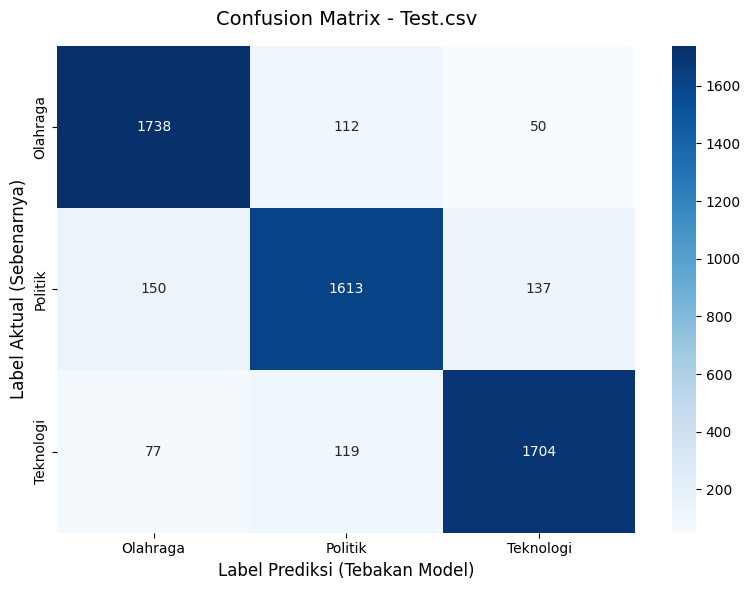

In [29]:
# ==========================================
# TAHAP 5: PENGUJIAN FINAL (TEST.CSV)
# ==========================================
print("\n" + "="*50)
print("PENGUJIAN FINAL MENGGUNAKAN TEST.CSV")
print("="*50)

# Menebak data test.csv
y_pred_final = dt_model.predict(X_test_final)
acc_test_final = accuracy_score(y_test, y_pred_final)

print(f"\nAKURASI FINAL (Real-World Data): {acc_test_final * 100:.2f}%\n")
print(classification_report(y_test, y_pred_final, target_names=dt_model.classes_))

# Visualisasi Confusion Matrix untuk Test Final
print("\nCONFUSION MATRIX - TEST FINAL")
print("-" * 30)
print("Menampilkan visualisasi Confusion Matrix...")

# Menghitung matriks
cm_final = confusion_matrix(y_test, y_pred_final, labels=dt_model.classes_)

# Visualisasi dengan Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dt_model.classes_, 
            yticklabels=dt_model.classes_)
plt.title('Confusion Matrix - Test.csv', fontsize=14, pad=15)
plt.ylabel('Label Aktual (Sebenarnya)', fontsize=12)
plt.xlabel('Label Prediksi (Tebakan Model)', fontsize=12)
plt.tight_layout()
plt.show()